In [1]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision import transforms
import numpy as np
import rasterio
from rasterio import features
from skimage.util import view_as_windows
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import rasterio
from rasterio.transform import from_origin
import glob

In [2]:
import torch
import subprocess

print("="*60)
print("GPU INFORMATION")
print("="*60)

if torch.cuda.is_available():
    print(f"✅ CUDA is available!")
    print(f"GPU Count      : {torch.cuda.device_count()}")
    print(f"Current GPU    : {torch.cuda.current_device()}")
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
    
    # Total VRAM
    total_vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Total VRAM     : {total_vram:.2f} GB")
    
    # Currently allocated
    allocated = torch.cuda.memory_allocated(0) / (1024**3)
    reserved = torch.cuda.memory_reserved(0) / (1024**3)
    print(f"Allocated      : {allocated:.2f} GB")
    print(f"Reserved       : {reserved:.2f} GB")
    print(f"Free VRAM      : {total_vram - reserved:.2f} GB")
    
else:
    print("❌ CUDA is NOT available. Running on CPU.")

print("="*60)

GPU INFORMATION
✅ CUDA is available!
GPU Count      : 1
Current GPU    : 0
GPU Name       : NVIDIA GeForce RTX 4050 Laptop GPU
Total VRAM     : 6.00 GB
Allocated      : 0.00 GB
Reserved       : 0.00 GB
Free VRAM      : 6.00 GB


In [3]:
# === Settings ===
# === Settings ===
image_path = r"D:\ML_Learn\Deep learning\wb_fcc_bhu_all.tif"
shapefile_path = r"D:\ML_Learn\Deep learning\train_lakes.shp"
name_of_model_to_save = r"D:\ML_Learn\Deep learning\best_model_12.pth"
output_folder = r"D:\ML_Learn\Deep learning\patches"
patch_size = 256
stride = 128

os.makedirs(os.path.join(output_folder, "images"), exist_ok=True)
os.makedirs(os.path.join(output_folder, "masks"), exist_ok=True)

# === Load image ===
with rasterio.open(image_path) as src:
    image = src.read().transpose(1, 2, 0)
    transform = src.transform
    crs = src.crs
    raster_shape = (src.height, src.width)

# === Rasterize vector lakes ===
lakes = gpd.read_file(shapefile_path)
lakes = lakes[lakes.geometry.notnull() & lakes.geometry.is_valid]
if lakes.crs != crs:
    lakes = lakes.to_crs(crs)

mask = features.rasterize(
    [(geom, 1) for geom in lakes.geometry],
    out_shape=raster_shape,
    transform=transform,
    fill=0,
    dtype=np.uint8
)

# === Generate overlapping patches ===
img_patches = view_as_windows(image, (patch_size, patch_size, image.shape[2]), step=stride)
mask_patches = view_as_windows(mask, (patch_size, patch_size), step=stride)

img_patches = img_patches.reshape(-1, patch_size, patch_size, image.shape[2])
mask_patches = mask_patches.reshape(-1, patch_size, patch_size)

print(f"🔍 Total generated patches before filtering: {len(img_patches)}")

# === Save valid patches only ===
valid_count = 0

for i, (img_patch, mask_patch) in enumerate(zip(img_patches, mask_patches)):
    if np.all(mask_patch == 0):
        continue

    img_patch = img_patch.astype(np.uint8)
    # img_patch = img_patch.astype(np.float32) # / 255.0  # Normalize here
    np.save(os.path.join(output_folder, "images", f"img_{valid_count:05d}.npy"), img_patch)
    np.save(os.path.join(output_folder, "masks", f"mask_{valid_count:05d}.npy"), mask_patch)
    valid_count += 1

print(f"✅ Done: {valid_count} valid patches saved")

🔍 Total generated patches before filtering: 41890
✅ Done: 2661 valid patches saved


In [4]:
# === Dataset ===
class GlacierLakeDataset(Dataset):
    
    """Define a custom dataset loader for PyTorch. It will load image + mask data (from .npy files), 
    transform images for input to a model, and return them as tensors. 
    Inherits from torch.utils.data.Dataset. The class lets you plug it into a PyTorch DataLoader for 
    training or validation, shuffling, multiprocessing, etc"""
    
    def __init__(self, img_dir, mask_dir, mean, std):
        self.image_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.npy')])
        self.mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.npy')])
        assert len(self.image_files) == len(self.mask_files)
        
        self.mean = mean
        self.std = std
        # Apply preprocessing / normalization to images
        self.transform = transforms.Compose([
            transforms.ToTensor(),               # [H,W,C] → [C,H,W] and scales 0–255 → 0–1
            transforms.Normalize(mean, std)      # expects input already in [0–1]
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = np.load(self.image_files[idx])  # Already normalized [0–1]
        mask = np.load(self.mask_files[idx])
        
        image_tensor = self.transform(image)
        
        # image_tensor = transforms.ToTensor()(image)
        # image_tensor = transforms.Normalize(self.mean, self.std)(image_tensor)
        
        mask_tensor = torch.from_numpy(mask).long()
        return image_tensor, mask_tensor


In [5]:
# Calculate mean and std of the images
mean_sum = np.zeros(3)
squared_sum = np.zeros(3)
n_pixels = 0

files = sorted(glob.glob(os.path.join(output_folder, 'images', '*.npy')))
for f in files:
    # arr = np.load(f)
    arr = np.load(f).astype(np.float32)/ 255.0
    flat = arr.reshape(-1, 3)
    mean_sum += flat.sum(axis=0)
    squared_sum += (flat ** 2).sum(axis=0)
    n_pixels += flat.shape[0]

mean = mean_sum / n_pixels
std = np.sqrt((squared_sum / n_pixels) - (mean ** 2))
print("Mean:", mean)
print("Std:", std)

Mean: [0.62472587 0.57435481 0.36799966]
Std: [0.25897954 0.25265792 0.30117054]


In [6]:
#  The ResNet backbone was trained on ImageNet using mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225] for normalization.
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

In [7]:
# === Load dataset ===
dataset = GlacierLakeDataset(os.path.join(output_folder, 'images'), 
                             os.path.join(output_folder, 'masks'), 
                             mean, std)

val_size = int(0.3 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# ==================== DATALOADERS (Optimized for RTX 4050 6GB) ====================
train_loader = DataLoader(
    train_dataset, 
    batch_size=2,                    # Increase to 3 or 4 later if possible
    shuffle=True, 
    num_workers=0,                      # Adjust based on your CPU cores and memory, for windows, 0 is often safer to avoid issues with multiprocessing
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=4,
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

# === Model - DeepLabV3 + ResNet50 =============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from torchvision.models.segmentation import deeplabv3_resnet50

model = deeplabv3_resnet50(
    weights=None,
    weights_backbone="IMAGENET1K_V1",
    num_classes=2
)

model = model.to(device)

# ==================== Mixed Precision Setup (Updated) ========================
from torch.amp import GradScaler, autocast   # New recommended way

scaler = GradScaler(device='cuda')   # Fixed deprecation warning

print("✅ Model (DeepLabV3 + ResNet50) loaded successfully on GPU!")
print(torch.cuda.memory_summary(device=None, abbreviated=True))

Using device: cuda
✅ Model (DeepLabV3 + ResNet50) loaded successfully on GPU!
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 157383 KiB | 157383 KiB | 157383 KiB |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         | 157383 KiB | 157383 KiB | 157383 KiB |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      | 155042 KiB | 155042 KiB | 155042 KiB |

In [8]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.1f} MB")
print(f"GPU Memory Reserved: {torch.cuda.memory_reserved(0)/1024**2:.1f} MB")
print(f"GPU Memory Total: {torch.cuda.get_device_properties(0).total_memory/1024**2:.1f} MB")

CUDA: True
GPU Memory Allocated: 153.7 MB
GPU Memory Reserved: 172.0 MB
GPU Memory Total: 6140.5 MB


In [10]:
from sklearn.metrics import confusion_matrix

def compute_metrics(preds, labels, num_classes=2):
    preds = preds.flatten()
    labels = labels.flatten()
    cm = confusion_matrix(labels, preds, labels=list(range(num_classes)))
    
    ious = []
    f1s = []
    for cls in range(num_classes):
        tp = cm[cls, cls]
        fp = cm[:, cls].sum() - tp
        fn = cm[cls, :].sum() - tp
        denom = tp + fp + fn
        iou = tp / denom if denom > 0 else float('nan')
        ious.append(iou)

        denom_f1 = (2 * tp + fp + fn)
        f1 = (2 * tp) / denom_f1 if denom_f1 > 0 else float('nan')
        f1s.append(f1)

    return ious, f1s

In [11]:
# ====================== TRAINING LOOP (Optimized) ======================
criterion = nn.CrossEntropyLoss(ignore_index=255)  # Add ignore_index if you have it
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Mixed Precision
from torch.amp import GradScaler, autocast
scaler = GradScaler(device='cuda')

best_f1 = 0.0
patience = 5                    # Increased patience
patience_counter = 0

train_losses = []
val_losses = []
ious_score = []
f1s_score = []

num_epochs = 50                 # You can increase later

print("🚀 Starting Training...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()

    # ==================== TRAINING ====================
    for imgs, masks in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(imgs)['out']
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ==================== VALIDATION ====================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(imgs)['out']
                loss = criterion(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(masks.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Compute metrics
    all_preds = np.concatenate([p.reshape(-1) for p in all_preds])
    all_labels = np.concatenate([l.reshape(-1) for l in all_labels])
    
    ious, f1s = compute_metrics(all_preds, all_labels, num_classes=2)
    mean_iou = np.nanmean(ious)
    mean_f1 = np.nanmean(f1s)

    ious_score.append(mean_iou)
    f1s_score.append(mean_f1)

    end.record()
    torch.cuda.synchronize()
    epoch_time = start.elapsed_time(end) / 1000

    # ==================== PRINT PROGRESS ====================
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_time:.1f}s")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"   Mean IoU : {mean_iou:.4f} | Mean F1 : {mean_f1:.4f}")

    # Early Stopping & Model Saving
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        patience_counter = 0
        torch.save(model.state_dict(), name_of_model_to_save)
        print(f"   ✅ Best model saved! (F1: {mean_f1:.4f})")
    else:
        patience_counter += 1
        print(f"   ⚠️ No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

    print("-" * 70)

print("\n✅ Training Completed!")

🚀 Starting Training...

Epoch [1/50] | Time: 81.8s
   Train Loss: 0.0224 | Val Loss: 0.0160
   Mean IoU : 0.8757 | Mean F1 : 0.9295
   ✅ Best model saved! (F1: 0.9295)
----------------------------------------------------------------------
Epoch [2/50] | Time: 83.6s
   Train Loss: 0.0145 | Val Loss: 0.0148
   Mean IoU : 0.8691 | Mean F1 : 0.9252
   ⚠️ No improvement. Patience: 1/5
----------------------------------------------------------------------
Epoch [3/50] | Time: 78.6s
   Train Loss: 0.0132 | Val Loss: 0.0175
   Mean IoU : 0.8347 | Mean F1 : 0.9017
   ⚠️ No improvement. Patience: 2/5
----------------------------------------------------------------------
Epoch [4/50] | Time: 78.5s
   Train Loss: 0.0143 | Val Loss: 0.0103
   Mean IoU : 0.9039 | Mean F1 : 0.9470
   ✅ Best model saved! (F1: 0.9470)
----------------------------------------------------------------------
Epoch [5/50] | Time: 100.6s
   Train Loss: 0.0098 | Val Loss: 0.0099
   Mean IoU : 0.9096 | Mean F1 : 0.9505
   ✅ Be

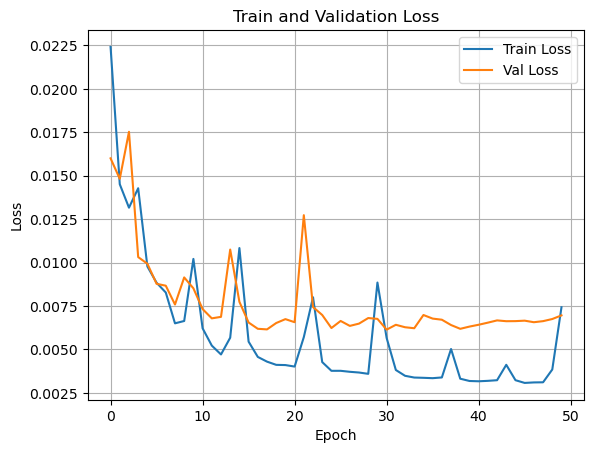

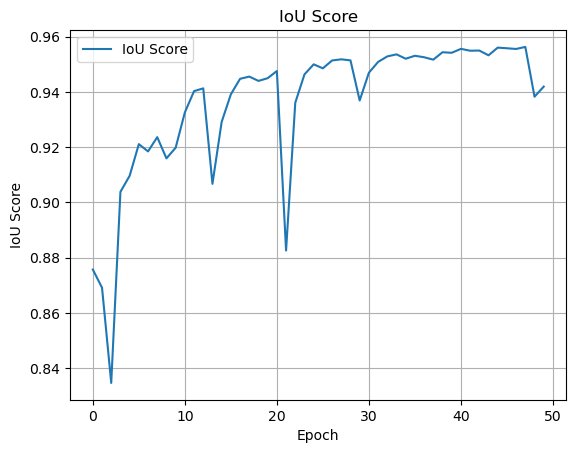

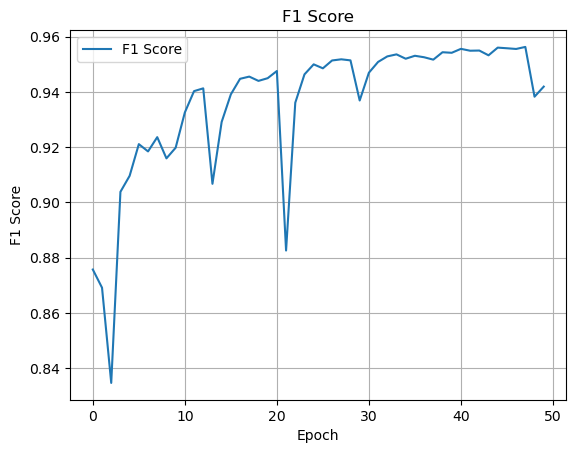

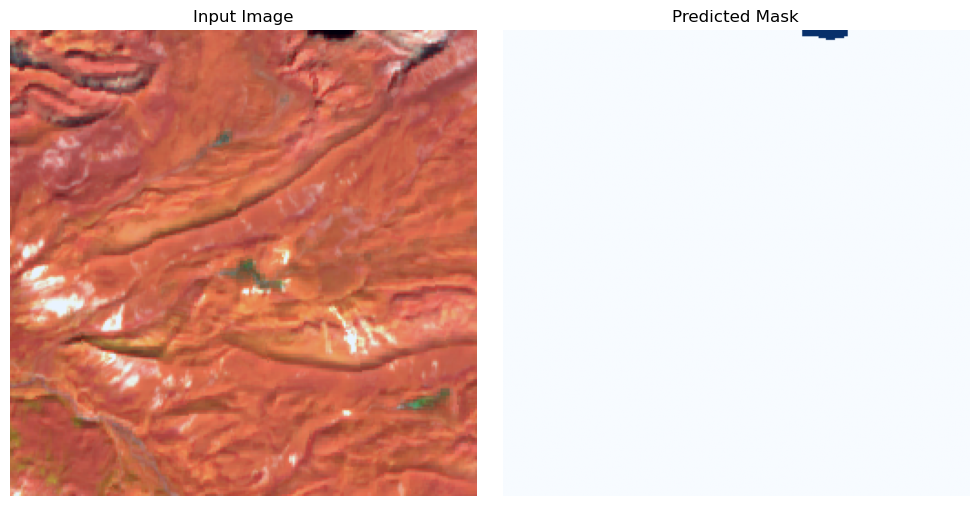

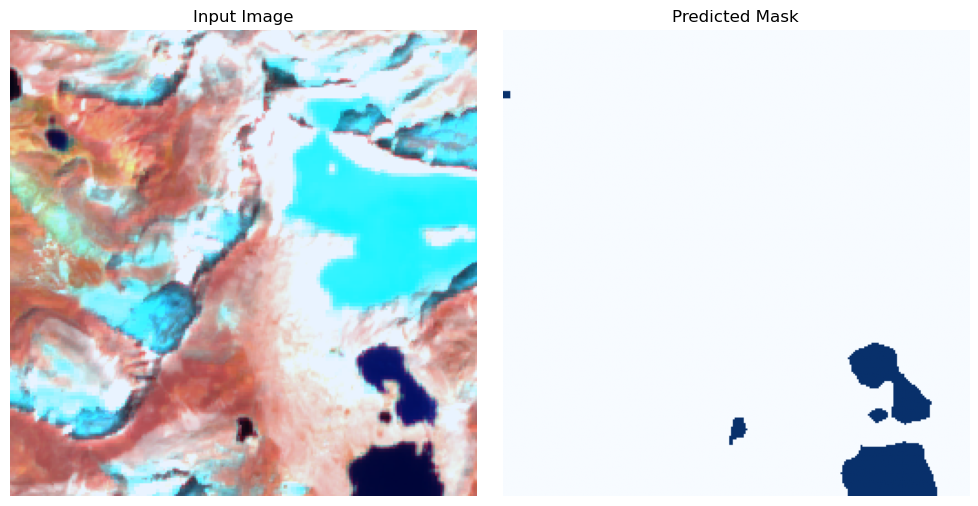

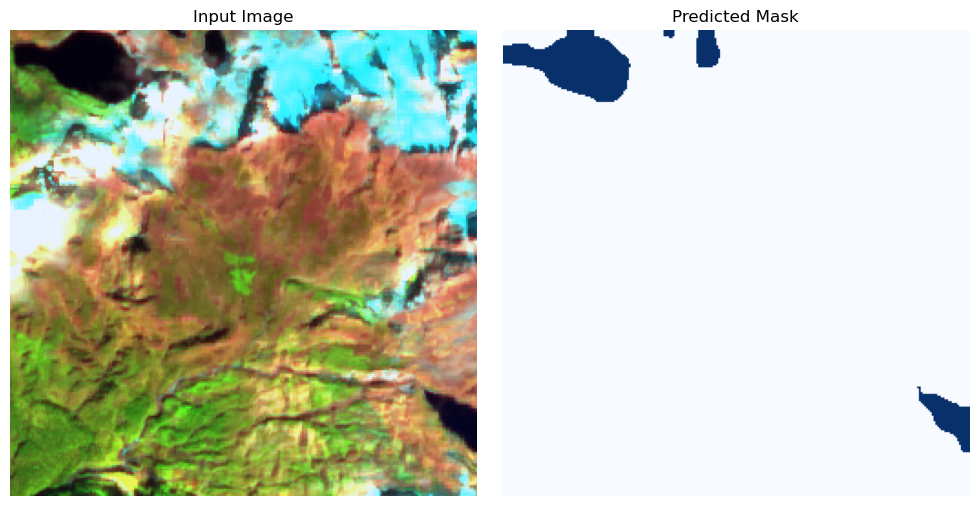

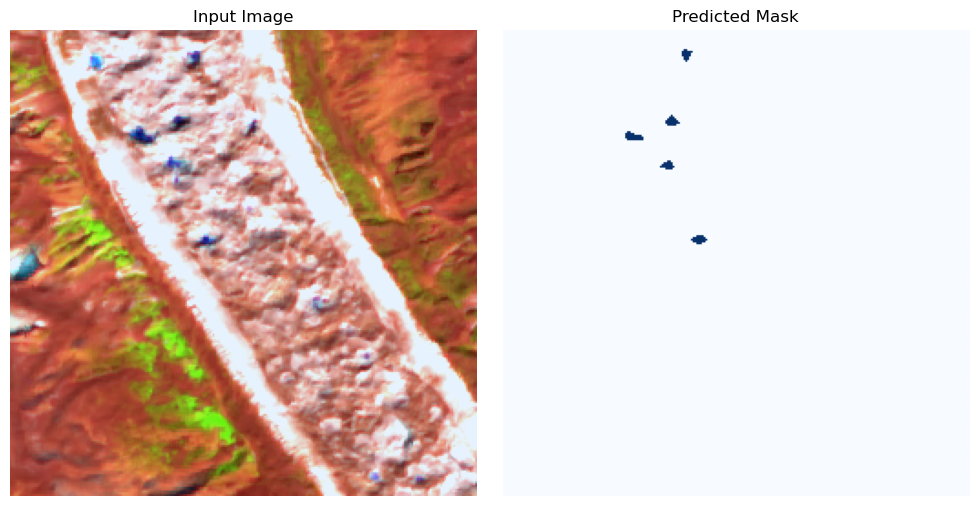

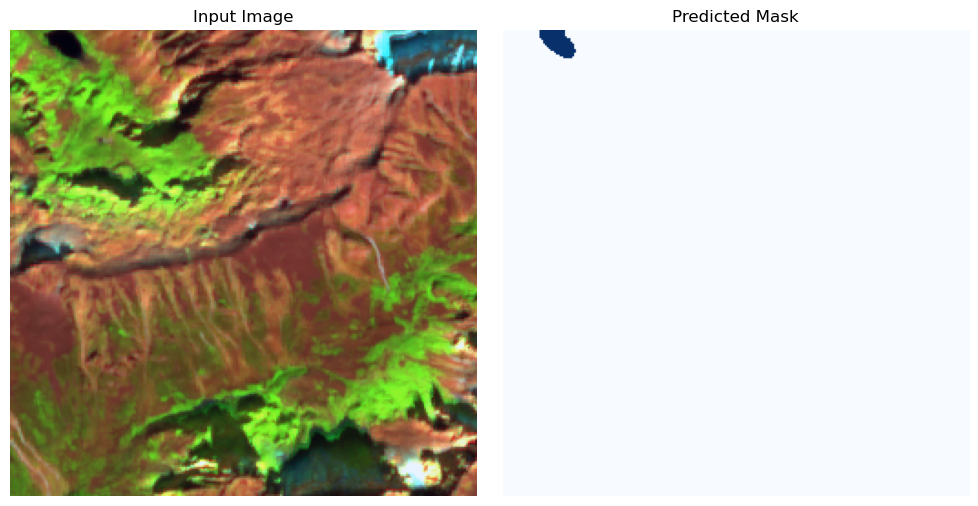

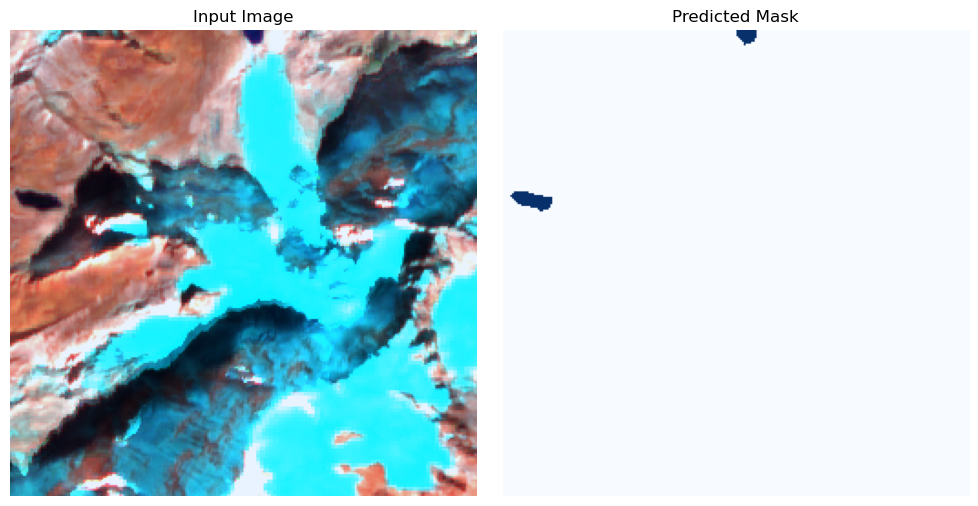

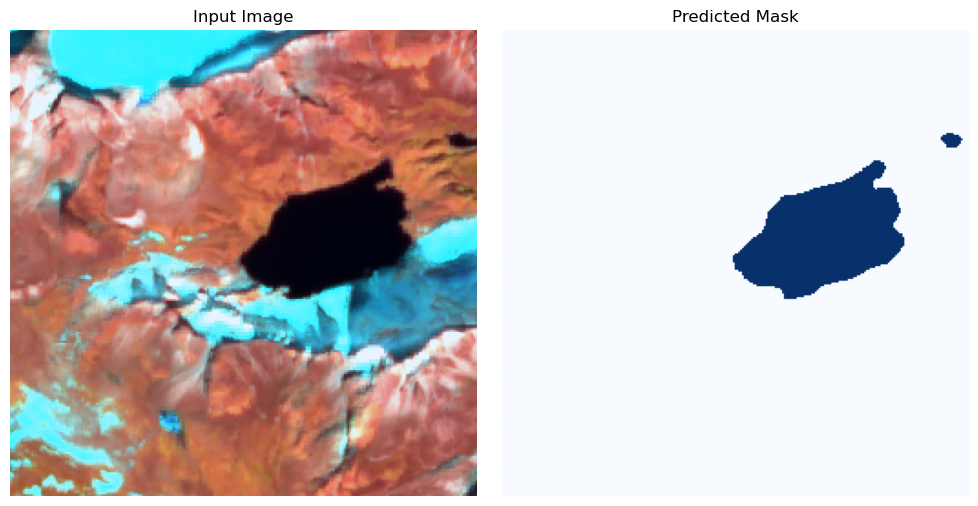

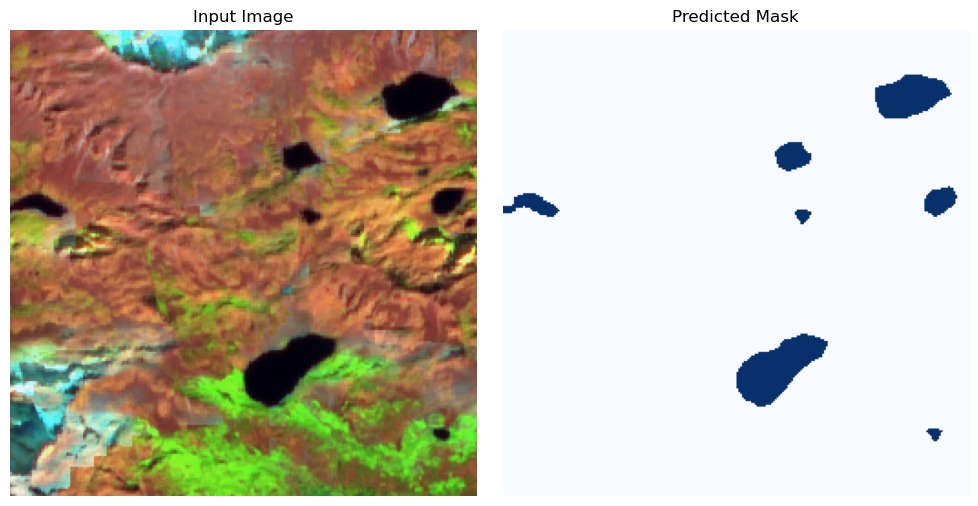

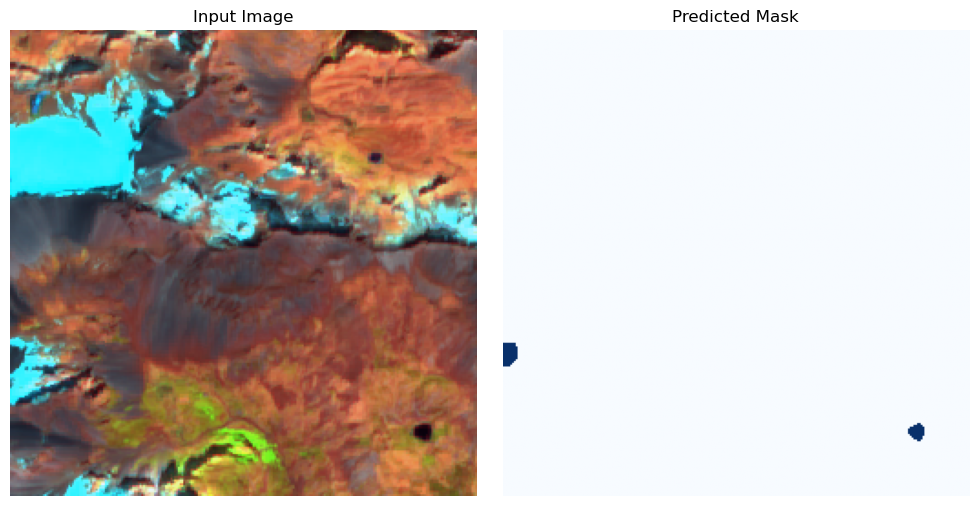

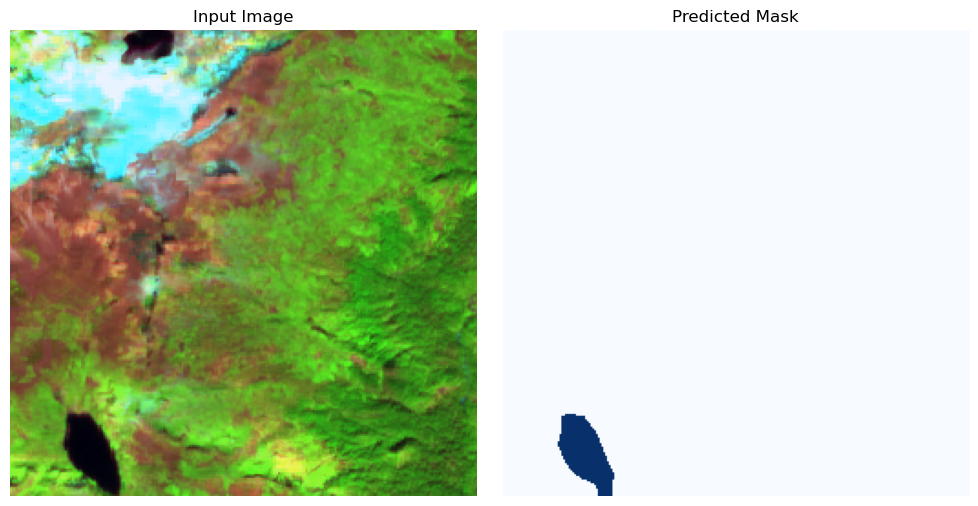

In [12]:
# === Plot losses ===
fig, ax = plt.subplots()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

fig, ax = plt.subplots()
plt.plot(ious_score, label='IoU Score')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.title('IoU Score')
plt.legend()
plt.grid(True)
plt.show()

fig, ax = plt.subplots()
plt.plot(ious_score, label='F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

# === Inference visualization ===
def predict_and_visualize(model, input_tensor):
    model.eval()
    with torch.no_grad():
        img_tensor = input_tensor.unsqueeze(0).float().to(device)
        output = model(img_tensor)['out']
        pred_mask = output.argmax(1).squeeze().cpu().numpy()

    input_img = input_tensor.cpu().numpy().transpose(1, 2, 0)
    input_img = (input_img - input_img.min()) / (input_img.max() - input_img.min())

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(input_img)
    ax[0].set_title("Input Image")
    ax[0].axis('off')
    ax[1].imshow(pred_mask, cmap='Blues')
    ax[1].set_title("Predicted Mask")
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

for j in range(20, 30):
    img_tensor, _ = val_dataset[j]
    predict_and_visualize(model, img_tensor)

In [13]:
# For prediction==========================================================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision import transforms
import numpy as np
import rasterio
from rasterio import features
from skimage.util import view_as_windows
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import rasterio
from rasterio.transform import from_origin
import glob

import rasterio
import numpy as np

base_path = r"D:\ML_Learn\Deep learning\Browser_images"

b08_path = base_path + r"\B08.tiff"
b04_path = base_path + r"\B04.tiff"
b03_path = base_path + r"\B03.tiff"

with rasterio.open(b08_path) as src:
    b08 = src.read(1)
    profile = src.profile

with rasterio.open(b04_path) as src:
    b04 = src.read(1)

with rasterio.open(b03_path) as src:
    b03 = src.read(1)

print("B08 dtype/min/max:", b08.dtype, b08.min(), b08.max())
print("B04 dtype/min/max:", b04.dtype, b04.min(), b04.max())
print("B03 dtype/min/max:", b03.dtype, b03.min(), b03.max())
print("Shapes:", b08.shape, b04.shape, b03.shape)

import numpy as np

for name, band in [("B08", b08), ("B04", b04), ("B03", b03)]:
    nodata_pixels = np.sum(band == 65535)
    total_pixels = band.size
    valid = band[band < 65535]
    print(f"{name}: {nodata_pixels}/{total_pixels} nodata pixels ({100*nodata_pixels/total_pixels:.2f}%)")
    print(f"   Valid data range: {valid.min()} to {valid.max()}, median: {np.median(valid):.0f}")

In [22]:
with rasterio.open(image_path) as src:
    print("dtype:", src.dtypes)
    print("bands:", src.count)

dtype: ('uint16', 'uint16', 'uint16')
bands: 3


In [23]:
import rasterio
import numpy as np

image_path = r"D:\ML_Learn\Deep learning\Nepal.tiff"
output_path = r"D:\ML_Learn\Deep learning\Nepal_8bit.tiff"

def to_uint8(band, nodata_val=65535, low_pct=2, high_pct=98):
    valid = band[band != nodata_val]
    lo, hi = np.percentile(valid, [low_pct, high_pct])
    stretched = np.clip((band.astype(np.float32) - lo) / (hi - lo) * 255, 0, 255)
    stretched[band == nodata_val] = 0
    return stretched.astype(np.uint8)

with rasterio.open(image_path) as src:
    data = src.read()  # shape (3, H, W)
    profile = src.profile

converted = np.stack([to_uint8(data[i]) for i in range(3)], axis=0)

profile.update(dtype='uint8', nodata=None)

with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(converted)

print("Saved:", output_path)
print("New dtype check:")
with rasterio.open(output_path) as src:
    print(src.dtypes, src.count, src.shape)

Saved: D:\ML_Learn\Deep learning\Nepal_8bit.tiff
New dtype check:
('uint8', 'uint8', 'uint8') 3 (1841, 2500)


In [38]:
image_path = r"D:\ML_Learn\Deep learning\Nepal_8bit.tiff"
output_folder = r"D:\ML_Learn\Deep learning\outputlakes"
trained_model = r"D:\ML_Learn\Deep learning\best_model_12.pth"

patch_size = 256
stride = 128
mean_value = [0.485, 0.456, 0.406]
std_value = [0.229, 0.224, 0.225]


with rasterio.open(image_path) as src:
    image = src.read().transpose(1, 2, 0)
    transform = src.transform
    crs = src.crs
    raster_shape = (src.height, src.width)

In [39]:
metadata = []
idx = 0
rows = range(0, raster_shape[0] - patch_size + 1, stride)
cols = range(0, raster_shape[1] - patch_size + 1, stride)

for row_idx, row in enumerate(rows):
    for col_idx, col in enumerate(cols):
        img_patch = image[row:row+patch_size, col:col+patch_size, :]
        # mask_patch = mask[row:row+patch_size, col:col+patch_size]
        
        metadata.append((idx, row, col))
        idx += 1

# Save metadata for later
np.save(os.path.join(output_folder, "metadata.npy"), metadata)
metadata = np.load(os.path.join(output_folder, "metadata.npy"), allow_pickle=True)

def save_mask_geotiff(mask_array, out_path, transform, crs):
    height, width = mask_array.shape
    with rasterio.open(
        out_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=mask_array.dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(mask_array, 1)

def transform_fn(patch):
    # Normalize patch values to float32
    # tensor = torch.from_numpy(patch.astype(np.float32) / 255.0)
    # tensor = tensor.to(dtype=torch.float32)              # Ensure float32
    # tensor = tensor.permute(2, 0, 1)                      # Change HWC → CHW
    # Only normalize if there are non-zero pixels
    tensor = torch.from_numpy(patch.astype(np.float32) / 255.0).permute(2, 0, 1)
    if torch.any(tensor != 0):
        tensor = transforms.Normalize(mean_value, std_value)(tensor)
    return tensor

def sliding_window_prediction(image, model, patch_size, stride, device, transform_fn):
    """
    image: np.array of shape (H, W, C)
    model: segmentation model
    transform_fn: function that transforms patch (H, W, C) to tensor (C, H, W)

    Input image in (H, W, C)

    Overlap-aware prediction with averaging (output_mask, count_mask)

    Skip patches that are entirely black ([0, 0, 0] across all pixels)
    """
    model.eval() # Set to eval mode for inference
    height, width, _ = image.shape
    output_mask = np.zeros((height, width), dtype=np.float32)
    count_mask = np.zeros((height, width), dtype=np.float32)

    for row in range(0, height - patch_size + 1, stride):
        for col in range(0, width - patch_size + 1, stride):
            patch = image[row:row+patch_size, col:col+patch_size]  # shape: (H, W, C) # Numpy shape

            # Skip patch if all pixels across all bands are zero
            if np.all(patch == 0):
                continue

            norm_patch = transform_fn(patch)  # should return tensor: (C, H, W) in tensor format
            input_tensor = norm_patch.unsqueeze(0).to(device)  # shape: (1, C, H, W)་#  batches shaped (B, C, H, W) (

            with torch.no_grad():
                pred = model(input_tensor)['out']
                pred_mask = pred.argmax(1).squeeze().cpu().numpy()  # shape: (H, W)

            output_mask[row:row+patch_size, col:col+patch_size] += pred_mask.astype(np.float32)
            count_mask[row:row+patch_size, col:col+patch_size] += 1.0

    # Avoid division by zero
    count_mask[count_mask == 0] = 1
    output_mask = output_mask / count_mask
    return np.rint(output_mask).astype(np.uint8)

In [40]:
import torch

sd = torch.load(trained_model, map_location='cpu', weights_only=True)

print("Total keys:", len(sd))
print()
print("First 10 keys:")
for k in list(sd.keys())[:10]:
    print(" ", k)
print()
print("Classifier-related keys:")
for k in sd.keys():
    if 'classifier' in k:
        print(" ", k, "->", sd[k].shape)

Total keys: 362

First 10 keys:
  backbone.conv1.weight
  backbone.bn1.weight
  backbone.bn1.bias
  backbone.bn1.running_mean
  backbone.bn1.running_var
  backbone.bn1.num_batches_tracked
  backbone.layer1.0.conv1.weight
  backbone.layer1.0.bn1.weight
  backbone.layer1.0.bn1.bias
  backbone.layer1.0.bn1.running_mean

Classifier-related keys:
  classifier.0.convs.0.0.weight -> torch.Size([256, 2048, 1, 1])
  classifier.0.convs.0.1.weight -> torch.Size([256])
  classifier.0.convs.0.1.bias -> torch.Size([256])
  classifier.0.convs.0.1.running_mean -> torch.Size([256])
  classifier.0.convs.0.1.running_var -> torch.Size([256])
  classifier.0.convs.0.1.num_batches_tracked -> torch.Size([])
  classifier.0.convs.1.0.weight -> torch.Size([256, 2048, 3, 3])
  classifier.0.convs.1.1.weight -> torch.Size([256])
  classifier.0.convs.1.1.bias -> torch.Size([256])
  classifier.0.convs.1.1.running_mean -> torch.Size([256])
  classifier.0.convs.1.1.running_var -> torch.Size([256])
  classifier.0.convs.

In [41]:
import torch
from torchvision.models.segmentation import deeplabv3_resnet50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = deeplabv3_resnet50(
    weights=None,
    weights_backbone=None,
    num_classes=2
)
model = model.to(device)

model.load_state_dict(torch.load(trained_model, weights_only=True, map_location=device))
model.eval()

print(model.classifier[4])

Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))


In [42]:
full_pred = sliding_window_prediction(image, model, patch_size=256, stride=128, device=device, transform_fn=transform_fn)
save_mask_geotiff(full_pred, r"D:\ML_Learn\Deep learning\outputlakes\full_prediction_V14.tif", transform, crs)
print("✅ Full image prediction saved as GeoTIFF")

✅ Full image prediction saved as GeoTIFF


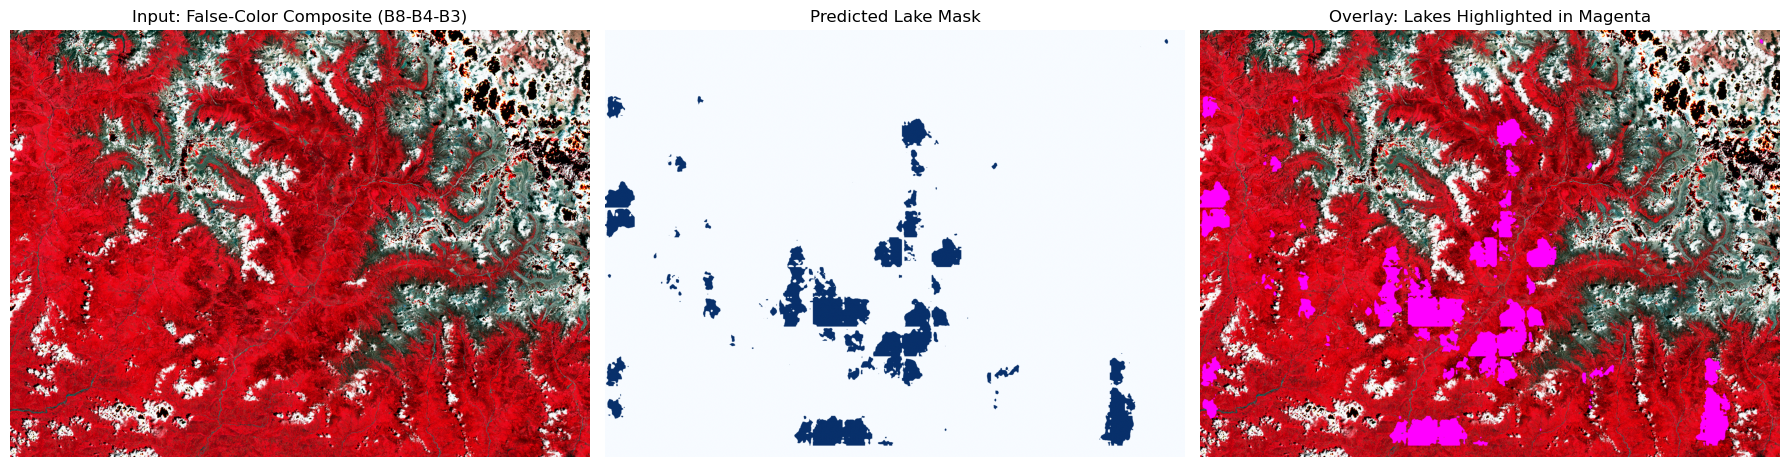

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# image is already loaded (H, W, 3) from earlier — your false-color composite
# full_pred is the predicted mask from the sliding_window_prediction call

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(image)
axs[0].set_title("Input: False-Color Composite (B8-B4-B3)")
axs[0].axis('off')

axs[1].imshow(full_pred, cmap='Blues')
axs[1].set_title("Predicted Lake Mask")
axs[1].axis('off')

overlay = image.copy()
lake_pixels = full_pred == 1
overlay[lake_pixels] = [255, 0, 255]  # magenta 

axs[2].imshow(overlay)
axs[2].set_title("Overlay: Lakes Highlighted in Magenta")
axs[2].axis('off')

plt.tight_layout()
plt.savefig(r"D:\ML_Learn\Deep learning\outputlakes\prediction_visualization.png", dpi=200, bbox_inches='tight')
plt.show()

In [44]:
import numpy as np

# image is the (H, W, 3) uint8 array already loaded for prediction
nodata_mask = np.all(image == 0, axis=-1)  # True where all 3 channels are black

overlap = np.sum((full_pred == 1) & nodata_mask)
total_predicted = np.sum(full_pred == 1)

print(f"Image shape: {image.shape}, nodata pixels: {nodata_mask.sum()}")
print(f"Predicted lake pixels: {total_predicted}")
print(f"Of those, overlapping nodata/black regions: {overlap} ({100*overlap/max(total_predicted,1):.1f}%)")

Image shape: (1841, 2500, 3), nodata pixels: 159037
Predicted lake pixels: 274529
Of those, overlapping nodata/black regions: 867 (0.3%)


In [45]:
import rasterio
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import numpy as np

# Vectorize connected lake regions from full_pred
shapes_gen = features.shapes(full_pred.astype(np.int32), mask=(full_pred == 1), transform=transform)

geometries = []
for geom, value in shapes_gen:
    geometries.append(shape(geom))

# Build a GeoDataFrame — already in WGS84 (EPSG:4326)
lakes_gdf = gpd.GeoDataFrame({'geometry': geometries}, crs=crs)

# Reproject to a metric CRS just for accurate area calculation
# UTM zone 45N covers this part of Nepal (roughly 84°E–90°E)
lakes_utm = lakes_gdf.to_crs(epsg=32645)
lakes_gdf['area_m2'] = lakes_utm.geometry.area

# Filter out tiny noise blobs — tune this threshold
lakes_gdf = lakes_gdf[lakes_gdf['area_m2'] > 1000]

print(f"Detected {len(lakes_gdf)} distinct lake regions after filtering")

# Centroid coordinates (already lat/lon since crs is EPSG:4326)
lakes_gdf['centroid'] = lakes_gdf.geometry.centroid
lakes_gdf['lat'] = lakes_gdf.centroid.y
lakes_gdf['lon'] = lakes_gdf.centroid.x

print(lakes_gdf[['lat', 'lon', 'area_m2']].to_string(index=False))

# Save for use in QGIS / Google Earth
out_path = r"D:\ML_Learn\Deep learning\outputlakes\detected_lakes.geojson"
lakes_gdf.drop(columns='centroid').to_file(out_path, driver='GeoJSON')
print(f"\nSaved: {out_path}")

Detected 136 distinct lake regions after filtering
      lat       lon      area_m2
28.544342 85.777333 3.115783e+05
28.536717 85.733607 1.469851e+03
28.457316 84.988594 6.858522e+05
28.434277 84.856353 2.797339e+04
28.446681 84.843871 6.586359e+06
28.422919 85.335229 1.162731e+05
28.409491 85.376423 7.654122e+04
28.394121 85.388612 2.561528e+05
28.408191 85.350785 1.401632e+07
28.379101 85.338258 1.472404e+03
28.374363 84.938851 8.543294e+04
28.367522 84.936240 2.946170e+03
28.365102 84.934475 5.892483e+03
28.362918 84.937958 2.754780e+05
28.356720 85.372282 1.178137e+04
28.359176 85.486855 5.801693e+05
28.362139 84.955742 3.081789e+06
28.345784 85.351101 9.868053e+04
28.361381 85.354553 4.864086e+06
28.334858 85.246872 1.473115e+03
28.325863 85.388205 6.776128e+04
28.321206 85.343401 1.812018e+05
28.308060 85.346466 3.210450e+06
28.312679 84.853411 1.412006e+07
28.288244 85.359574 1.768336e+05
28.279208 85.325707 1.473777e+03
28.277461 84.998734 1.577416e+05
28.270951 85.360352 1.326

C:\Users\LOQ\AppData\Local\Temp\ipykernel_16360\3451382145.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lakes_gdf['centroid'] = lakes_gdf.geometry.centroid
C:\Users\LOQ\AppData\Local\Temp\ipykernel_16360\3451382145.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lakes_gdf['lat'] = lakes_gdf.centroid.y
C:\Users\LOQ\AppData\Local\Temp\ipykernel_16360\3451382145.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lakes_gdf['lon'] = lakes_gdf.centroid.x



Saved: D:\ML_Learn\Deep learning\outputlakes\detected_lakes.geojson


In [47]:
import rasterio

with rasterio.open(r"D:\ML_Learn\Deep learning\Nepal_8bit.tiff") as src:
    bounds = src.bounds
    print("Image bounds (left, bottom, right, top):")
    print(bounds)

Image bounds (left, bottom, right, top):
BoundingBox(left=84.828186, bottom=27.926474, right=85.808716, top=28.562813)


In [48]:
import numpy as np

# Compute perimeter in the same metric CRS used for area
lakes_gdf['perimeter_m'] = lakes_utm.geometry.length

# Compactness: 1.0 = perfect circle, closer to 0 = irregular/elongated
lakes_gdf['compactness'] = (4 * np.pi * lakes_gdf['area_m2']) / (lakes_gdf['perimeter_m'] ** 2)

# Sort so you can see the full spread before picking a cutoff
lakes_sorted = lakes_gdf.sort_values('compactness', ascending=False)
print(lakes_sorted[['lat', 'lon', 'area_m2', 'compactness']].to_string(index=False))

      lat       lon      area_m2  compactness
28.536717 85.733607 1.469851e+03     0.785397
28.379101 85.338258 1.472404e+03     0.785396
28.365102 84.934475 5.892483e+03     0.785396
28.334858 85.246872 1.473115e+03     0.785395
28.279208 85.325707 1.473777e+03     0.785394
28.224077 85.341199 5.898024e+03     0.785393
28.190895 85.397678 5.899562e+03     0.785393
28.149244 85.099008 1.475821e+03     0.785392
28.132653 85.112344 1.476028e+03     0.785391
28.132653 85.096655 1.476049e+03     0.785391
28.077695 85.698701 1.476111e+03     0.785390
28.050216 85.290996 5.907654e+03     0.785389
28.063696 85.140191 2.953843e+03     0.699647
28.066462 85.714585 1.180998e+04     0.699641
28.367522 84.936240 2.946170e+03     0.698981
28.116105 85.237508 1.180873e+04     0.698126
28.066332 85.300262 1.181349e+04     0.698125
28.055271 85.510782 1.181279e+04     0.698125
28.088298 85.077914 5.463695e+04     0.687465
28.188209 84.950728 2.670655e+05     0.676504
28.288244 85.359574 1.768336e+05  

In [52]:
target_lat, target_lon = 28.083, 85.417

lakes_gdf['dist_to_gosaikunda'] = np.sqrt(
    (lakes_gdf['lat'] - target_lat)**2 + (lakes_gdf['lon'] - target_lon)**2
)
nearby = lakes_gdf.sort_values('dist_to_gosaikunda').head(10)
print(nearby[['lat', 'lon', 'area_m2', 'compactness', 'dist_to_gosaikunda']].to_string(index=False))

      lat       lon      area_m2  compactness  dist_to_gosaikunda
28.091406 85.403626 4.428685e+03     0.589043            0.015796
28.104526 85.387067 8.620244e+05     0.435186            0.036870
28.133052 85.441379 1.918311e+04     0.504531            0.055674
28.133926 85.393851 6.689185e+06     0.465201            0.055941
28.044567 85.477735 1.008640e+06     0.426652            0.071873
28.148826 85.375972 5.606840e+04     0.466661            0.077565
28.052982 85.345292 9.085346e+06     0.327487            0.077737
28.101196 85.337721 5.438180e+07     0.098702            0.081341
28.157540 85.379244 5.901449e+03     0.500952            0.083557
28.036156 85.346979 2.510962e+04     0.534064            0.084246
